# Segmentation
masking specific element and objects in the picture.

### 1. General method
a very precise method that allows a lot of flexibility.

### 2. CLIP guided method
another method that in combination with the CLIP model allows us to guide the segmentation using text prompts.



# Diffusion Models
they define a series of diffusion steps to slowly add random noise to data and then learn to reverse the diffusion process to construct new data samples from the noise.

#### **paper:** high-resolution image synthesis with latent diffusion models (2021)

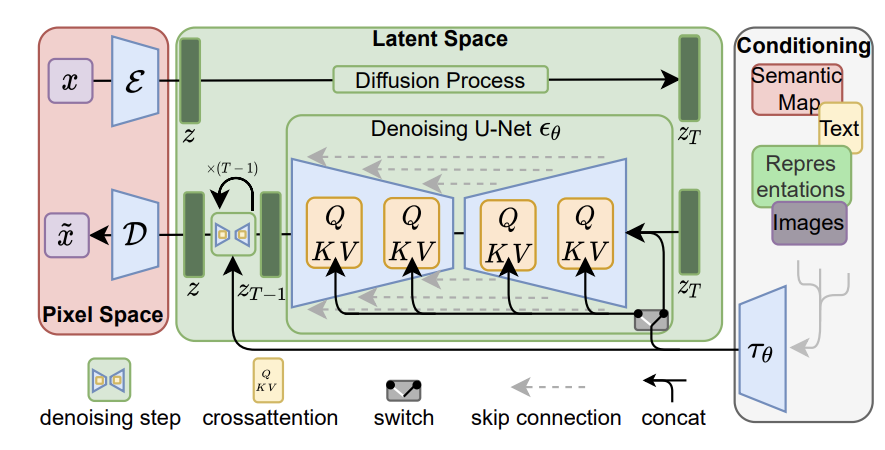

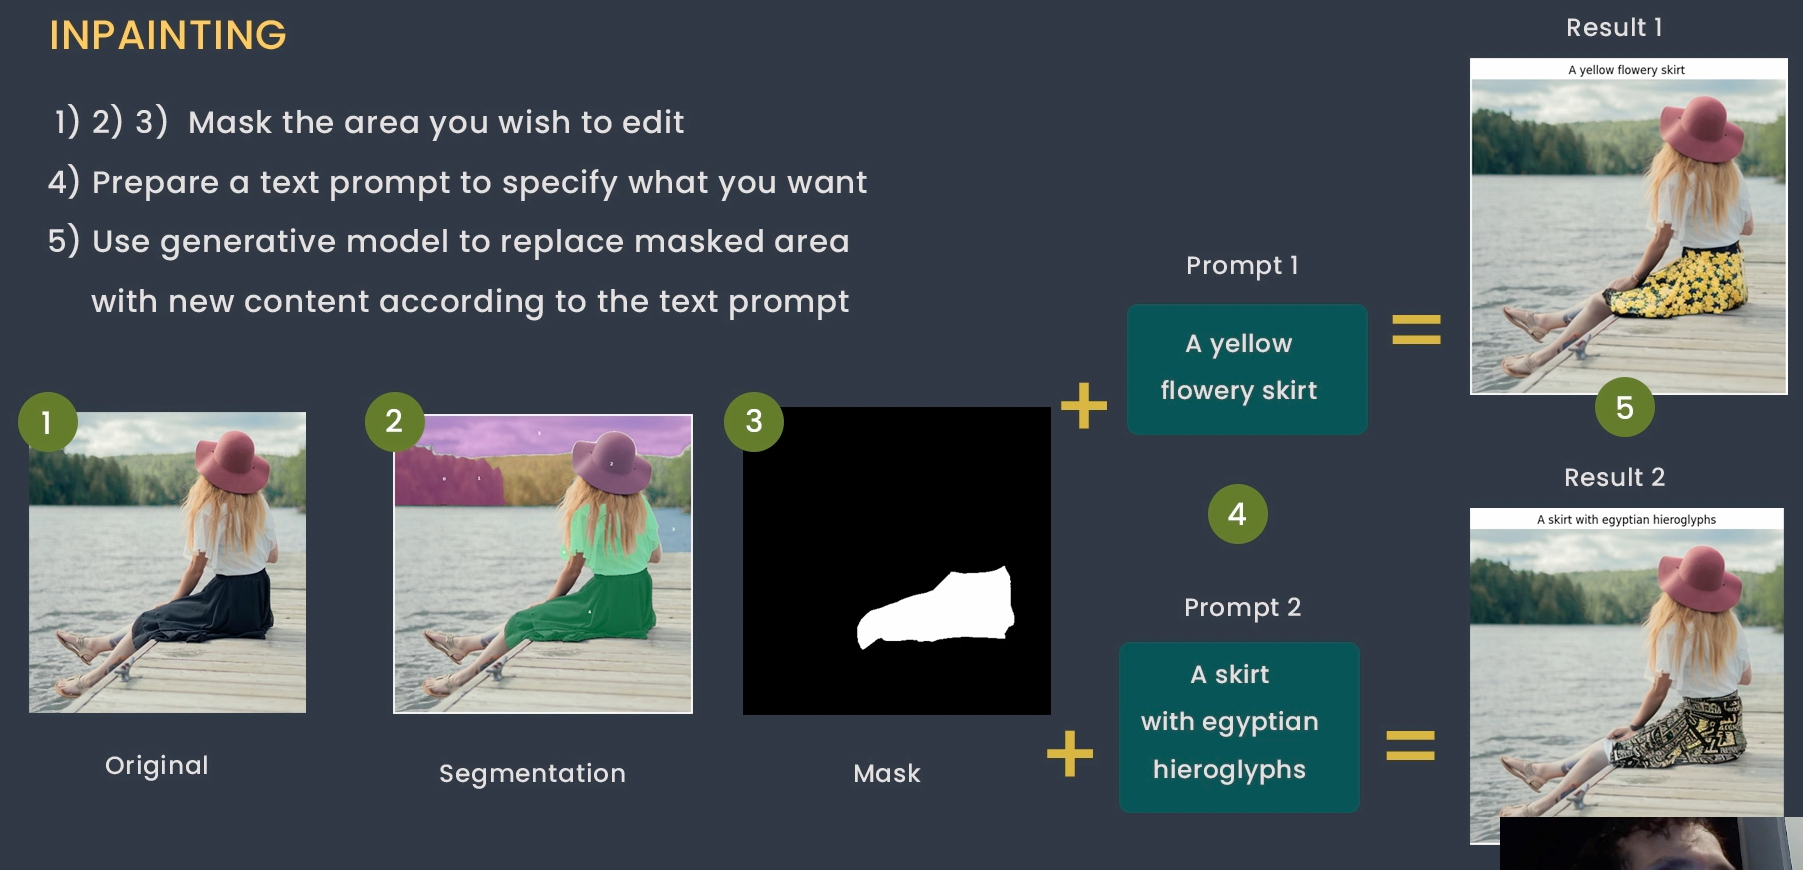

--------------------
this project combines **segmentation**, **image editing** and **generation**.

using segment anything from meta ai for segmenatation (apache licence 2.0) requirements: an image

using stable diffusion for inpainting requirements: an image + a mask + a text prompt

using gpt to generate visualisation function (optional, requires openai api)


In [ ]:
!pip install torch==2.6.0 torchvision==0.21.0 torchaudio==2.6.0 --index-url https://download.pytorch.org/whl/cu124 --force-reinstall

#### **installing libraries**
**regex:** advanced regular expressions library for searching and manipulating text

**tqdm:** fast, extensible progress bar for loops and iterable objects

**diffusers by hugging face:** provides pretrained vision and audio diffusion models, and serves as a modular toolbox for inference and training

**transfermers by hugging face:** provides apis and tools to easily download and train soa pretrained models.

**scipy:** scientific computing library for optimisation, integration, and other mathematical operations

**accelerate by hugging face:** training and inference at scale made simple, efficient and adaptable

**xformers:** optimises transformers architecture. toolbox to accelerate research on transformers

**opencv:** opencv is a library of programming functions mainly for real-time computer vision

In [ ]:
# general libraries
!pip install -q regex tqdm
#!pip install -q diffusers transformers accelerate scipy
#!pip install -q -U xformers
!pip install -q opencv-python

In [ ]:
!pip install diffusers transformers accelerate
!pip install xformers --index-url https://download.pytorch.org/whl/cu124

In [ ]:
# sam libraries
!pip install -q git+https://github.com/facebookresearch/segment-anything.git
!pip install -q pycocotools matplotlib onnxruntime onnx

In [ ]:
!pip install torch==2.6.0 torchvision==0.21.0 torchaudio==2.6.0 --index-url https://download.pytorch.org/whl/cu124 --force-reinstall

In [ ]:
# import libraries
import torch
from torchvision import transforms
from torchvision.transforms.functional import to_pil_image, to_tensor

import PIL, cv2
from PIL import Image

from io import BytesIO
from IPython.display import display
import base64, json, requests
from matplotlib import pyplot as plt

import numpy as np
import copy

from numpy import asarray

import sys

from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

**download segment anything checkpoint** called **sam_vit_h_4b8939.pth** and put it on the same folder where this notebook is.

**current link:** https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

(if this doesn't work, check: https://github.com/facebookresearch/segment-anything)

In [ ]:
# downloading checkpoint file to same folder where this notebook is
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

In [ ]:
# import stable diffusion model
from diffusers import StableDiffusionInpaintPipeline, EulerDiscreteScheduler

model_dir = "stabilityai/stable-diffusion-2-inpainting"

# the scheduler determine the algorithm used to produce new samples during the denosing process
scheduler = EulerDiscreteScheduler.from_pretrained(model_dir, subfolder="scheduler")

pipe = StableDiffusionInpaintPipeline.from_pretrained(model_dir,
                                                      scheduler=scheduler,
                                                      revision="fp16",
                                                      torch_dtype=torch.float16)

pipe = pipe.to("cuda")
pipe.enable_xformers_memory_efficient_attention()

In [ ]:
# example image
# link: https://unsplash.com/photos/AsJirOOLN_s
# photo by lac mcgregor, canada

target_width, target_height = 512, 512 # if there are memory issues, reduce the size
source_image = Image.open("/content/mix909-AsJirOOLN_s-unsplash.jpg")

width, height = source_image.size
print(f"Source image size: {width}x{height}")

# we make the image square
source_image = source_image.crop((0, height-width, width, height)) # box = (left, upper, right, lower)

# we resize the image to the targer dimensions (so that it uses less memory)
source_image = source_image.resize((target_width, target_height), Image.LANCZOS)
width, height = source_image.size
print(f"Target image size: {width}x{height}")

# we convert the image into an array in order to use it later with the segmentation model
segmentation_image = asarray(source_image)

display(source_image)

In [ ]:
# initialise segment anything model

sam_checkpoint = "/content/sam_vit_h_4b8939.pth"
model_type = "vit_h"

device = "cuda"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)


# pay attention to the pred_iou_thresh, the lower the more masks it will generate.
# make it higher to generate masks only of good quality and less number of them
mask_generator = SamAutomaticMaskGenerator(
    model = sam,
    points_per_side = 32,
    pred_iou_thresh=0.99, # a filtering threshold in [0, 1]
    stability_score_thresh=0.92,
    crop_n_layers=1,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=100,
    )

In [ ]:
# run segmentation model
masks = mask_generator.generate(segmentation_image)

# print number of masks generated and the keys attached to each of them
print(f"Number of masks generated: {len(masks)}")
print(masks[0].keys())

# intersection over union (iou) tell us the degree of overlap between two boxes
# in the case of object detection and segmentation, it refers to the overlap of the ground truth and prediction region

In [ ]:
# declare fuction to visualise the masks generated together with a number that identifies each of them

def show_anns(anns):
  if len(anns) == 0:
    return

  # sort masks by area in descending order
  sorted_anns = sorted(enumerate(anns), key=lambda x: x[1]['area'], reverse=True)
  ax = plt.gca()

  # disable autoscale to keep the image size consistent
  ax.set_autoscale_on(False)

  # iterate through each mask and display it on top of the original image
  for original_idx, ann in sorted_anns:
    m = ann['segmentation']
    img = np.ones((m.shape[0], m.shape[1], 3))

    # generate a random colour for the mask
    colour_mask = np.random.random((1, 3)).tolist()[0]
    for i in range(3):
      img[:, :, i] = colour_mask[i]

    # blend the mask with the image, using 0.35 as the alpha value for transparency
    ax.imshow(np.dstack((img, m*0.35)))

    # find contours of the mask to compute the centroid
    contours, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
      cnt = contours[0]
      M = cv2.moments(cnt)

      # compute the centroid of the mask if the moment is non-zero
      if M['m00'] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])

        # display the original index number (1-based) at the centroid of the mask
        # the text is white, bold, and has a font size of 16
        ax.text(cx, cy, str(original_idx), color = "white", fontsize=16, ha = "center", va = "center", fontweight = "bold")

In [ ]:
# display masks with a number identifying each of them

plt.figure(figsize=(20, 20))
plt.imshow(source_image)
show_anns(masks) # use masks[:-x] to only display the first masks of the list
plt.axis('off')
plt.show()

In [ ]:
# explore one of the keys of the mask
for i, values in enumerate(masks):
  print(f"{i}: Area: {values['area']}, | IoU: {values['predicted_iou']}")

  # iou: 0 means no overlap, 1 means perfect overlap

In [ ]:
# decide which mask you want to do inpainting with. in this case we pick the skirt which is mask number 3
mask_index = 3

segmentation_mask = masks[mask_index]['segmentation']
stable_diffusion_mask = PIL.Image.fromarray(segmentation_mask)
display(stable_diffusion_mask)

In [ ]:
# setup transformation prompts
num_images_per_prompt = 8
inpainting_prompts = ["a yellow flowery skirt", "a skirt with egyptian hieroglyphs", "a skirt with green turtles", "a skirt with pink apples", "a skirt full of text",  "red flowers", "blue flowers", "a zebra skirt"]
# inpainting_prompts = ["colourful flowery", "egyptian hieroglyphs", "green turtles", "pink apples"]

generator = torch.Generator(device="cuda").manual_seed(155) # 155, 77, ...

# run stable diffusion pipeline in inpainting mode
encoded_images = []
for i in range(num_images_per_prompt):
  image = pipe(prompt = inpainting_prompts[i],
               generator = generator,
               image=source_image,
               mask_image=stable_diffusion_mask).images[0]
  encoded_images.append(image)

In [ ]:
def create_image_grid(original_image, images, names, rows, columns):
    names = copy.copy(names)  # Create a copy of the names list to avoid modifying the external variable
    images = copy.copy(images)  # Create a copy of the images list to avoid modifying the external variable

    # Check if images is a tensor
    if torch.is_tensor(images):
        # Check if the number of tensor images and names is equal
        assert images.size(0) == len(names), "Number of images and names should be equal"

        # Check if there are enough images for the specified grid size
        assert images.size(0) >= (rows * columns) - 1 - 1, "Not enough images for the specified grid size"

        # Convert tensor images to PIL images and apply sigmoid normalization
        images = [to_pil_image(torch.sigmoid(img)) for img in images]
    else:
        # Check if the number of PIL images and names is equal
        assert len(images) == len(names), "Number of images and names should be equal"

    # Check if there are enough images for the specified grid size
    assert len(images) >= (rows * columns) - 1 - 1, "Not enough images for the specified grid size"

    # Add the original image to the beginning of the images list
    images.insert(0, original_image)

    # Add an empty name for the original image to the beginning of the names list
    names.insert(0, '')

    # Create a figure with specified rows and columns
    fig, axes = plt.subplots(rows, columns, figsize=(15, 15))

    # Iterate through the images and names
    for idx, (img, name) in enumerate(zip(images, names)):
        # Calculate the row and column index for the current image
        row, col = divmod(idx, columns)

        # Add the image to the grid
        axes[row, col].imshow(img, cmap='gray' if idx > 0 and torch.is_tensor(images) else None)

        # Set the title (name) for the subplot
        axes[row, col].set_title(name)

        # Turn off axes for the subplot
        axes[row, col].axis('off')

    # Iterate through unused grid cells
    for idx in range(len(images), rows * columns):
        # Calculate the row and column index for the current cell
        row, col = divmod(idx, columns)

        # Turn off axes for the unused grid cell
        axes[row, col].axis('off')

    # Adjust the subplot positions to eliminate overlaps
    plt.tight_layout()

    # Display the grid of images with their names
    plt.show()


In [ ]:
create_image_grid(source_image, encoded_images, inpainting_prompts, 2, 5)

# CLIP Segmentation

In [ ]:
# import clip and clipseg repositories

# install clip from openai
!pip install -q git+https://github.com/openai/CLIP.git

# install clipseg repo
!git clone https://github.com/timojl/clipseg

In [ ]:
# important: move into the clipseg folder
%cd /content/clipseg

In [ ]:
# get the weights for the clipseg model
# these weights don't have mit licence, they can only be used for research, not for commercial purposes
! wget https://owncloud.gwdg.de/index.php/s/ioHbRzFx6th32hn/download -O weights.zip
! unzip -d weights -j weights.zip

In [ ]:
# import clip and clipseg model
import clip
from models.clipseg import CLIPDensePredT

# load clipseg model
model = CLIPDensePredT(version='ViT-B/16', reduce_dim=64)
model.eval();

#non-strict mode: decoder weights only (no CLIP weights)
model.load_state_dict(torch.load('weights/rd64-uni.pth', map_location=torch.device('cpu')), strict=False);

In [ ]:
# import stable diffusion model
from diffusers import StableDiffusionInpaintPipeline, EulerAncestralDiscreteScheduler

model_dir = "stabilityai/stable-diffusion-2-inpainting"

# the scheduler determine the algorithm used to produce new samples during the denosing process
scheduler = EulerAncestralDiscreteScheduler.from_pretrained(model_dir, subfolder="scheduler")

pipe = StableDiffusionInpaintPipeline.from_pretrained(model_dir,
                                                      scheduler=scheduler,
                                                      revision="fp16",
                                                      torch_dtype=torch.float16)

pipe = pipe.to("cuda")
pipe.enable_xformers_memory_efficient_attention()

In [ ]:
# example image

target_width, target_height = 512, 512 # if there are memory issues, reduce the size
source_image = Image.open("mix909-AsJirOOLN_s-unsplash.jpg")

width, height = source_image.size
print(f"Source image size: {width}x{height}")

source_image = source_image.crop((0, height-width, width, height)) # box = (left, upper, right, lower)
source_image = source_image.resize((target_width, target_height), Image.LANCZOS)
print(f"Target image size: {source_image.size}")

# setup transformations to be applied to the image
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

tensor_image = transform(source_image).unsqueeze(0)

display(source_image)

In [ ]:
# create masks for the parts of the clothes to be identified

prompts = ['a hat', 'a dark skirt', 'shoes', 'a white shirt']

# use clipseg to identify elements in the picture
with torch.no_grad():
  preds = model(tensor_image.repeat(len(prompts), 1, 1, 1), prompts)[0]

In [ ]:
create_image_grid(source_image, preds, prompts, 2, 3)

In [ ]:
# decide which mask you want to do inpainting with. in this case we pick the skirt which is mask number 1.
mask_number = 0

# normalise mask values by computing the are under gaussian probability density function
# calculating the cumulative distribution
processed_mask = torch.special.ndtr(preds[mask_number][0])

stable_diffusion_mask = transforms.ToPILImage()(processed_mask)
display(stable_diffusion_mask)

In [ ]:
# setup transformation prompts
num_images_per_prompt = 8
#inpainting_prompts = ["a yellow flowery skirt", "a skirt with egyptian hieroglyphs", "a skirt with green turtles", "a skirt with pink apples", "a skirt full of text",  "red flowers", "blue flowers", "a zebra skirt"]
inpainting_prompts = ["colourful flowery", "hieroglyphs", "funny cats", "pink apples", "saturn", "a roll of toilet paper", "melting ice cream cone", "an open book"]

generator = torch.Generator(device="cuda").manual_seed(155) # 155, 77, ...

# run stable diffusion pipeline in inpainting mode
encoded_images = []
for i in range(num_images_per_prompt):
  image = pipe(prompt=inpainting_prompts[i], generator=generator, image=source_image, mask_image=stable_diffusion_mask).images[0]
  encoded_images.append(image)

In [ ]:
create_image_grid(source_image, encoded_images, inpainting_prompts, 2, 5)